In [1]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt

#**1**
Cuando no hay átomos no interactuantes, el cambio de la energía al invertir el spin es $ΔE=E_{nuevo} - E_{viejo} = -\mu_0H(-s_i) - (-\mu_0H(s_i)) = 2\mu_0 H  s_i$

In [9]:
def metropolis(red,T,H):
  mu0=4*np.pi*10**-7 #permitividad magnética
  kb=1.380649*10**-23 #constante de Boltzman
  N = red.shape[0]
  x,y = np.random.randint(0, N, size=2)
  espin_actual = red[x, y]
  dE = 2 * H * espin_actual*mu0
  if dE < 0:
    red[x, y] *= -1
  else:
    probabilidad = np.exp(-dE/(kb*T))
    if np.random.rand() < probabilidad:
      red[x, y] *= -1
  return red

In [12]:
def simular_magnetizacion(N, pasos_term, pasos_medida, T, H):

    red = np.random.choice([1, -1], size=(N, N))
    # Termalización
    for i in range(pasos_term):
        for i in range(N * N):
            metropolis(red,T, H)

    # Medición de la magnetización
    magnetizacion_total = 0

    for i in range(pasos_medida):
        for i in range(N * N):
            metropolis(red, T, H)
        magnetizacion_total += np.sum(red) / (N * N)

    # Retornar el promedio
    return magnetizacion_total / pasos_medida

#**2 y 3**

In [14]:
N = 20
temperaturas = [5, 15, 20]
campos_H = np.linspace(-30, 30, 40)
pasos_term = 100
pasos_medida = 100


Para un sistema de $N$ espines no interactuantes ($J=0$) en un campo magnético $H$, la función de partición canónica para un solo espín ($Z_1$) que puede tomar valores $s_i = \pm 1$ es:$$Z_1 = e^{-\beta(-\mu H)} + e^{-\beta(\mu H)} = e^{\beta \mu H} + e^{-\beta \mu H} = 2 \cosh(\beta \mu H)$$Donde $\beta = 1 / (k_B T)$. Como los átomos no interactúan, la función de partición total del sistema es $Z = (Z_1)^N$.La magnetización total promedio de este sistema se obtiene derivando el logaritmo de la función de partición respecto al campo magnético:$$M_{total} = \frac{1}{\beta} \frac{\partial \ln Z}{\partial H} = N \mu \tanh(\beta \mu H)$$

Por lo tanto, la magnetización media por espín es:$$M = \tanh\left(\frac{\mu_0 H}{k_B T}\right)$$

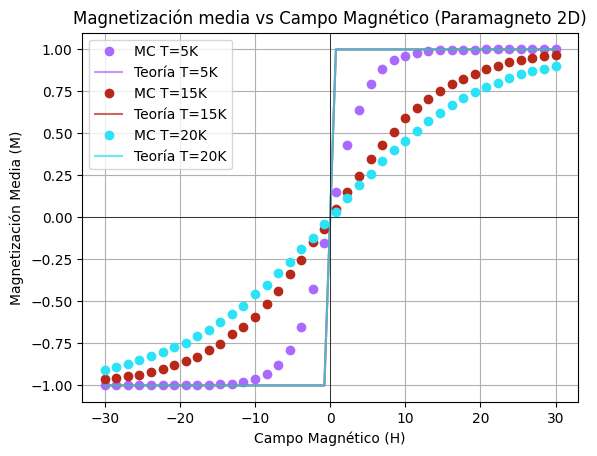

In [19]:
colores = ['#AA69FF', '#B72818', '#2BE2F7']

for i, T in enumerate(temperaturas):
    mag_simulada = []
    mag_teorica = []

    for H in campos_H:
        # 1. Simulación Monte Carlo
        m_sim = simular_magnetizacion(N, pasos_term, pasos_medida, T, H)
        mag_simulada.append(m_sim)

        mu0=4*np.pi*10**-7 #permitividad magnética
        kb=1.380649*10**-23 #constante de Boltzman
        m_teo = np.tanh(mu0*H / (kb*T))
        mag_teorica.append(m_teo)

    plt.plot(campos_H, mag_simulada, 'o', color=colores[i], label=f'MC T={T}K')
    plt.plot(campos_H, mag_teorica, '-', color=colores[i], alpha=0.7, label=f'Teoría T={T}K')
    plt.title('Magnetización media vs Campo Magnético (Paramagneto 2D)')
plt.xlabel('Campo Magnético (H)')
plt.ylabel('Magnetización Media (M)')
plt.legend()
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)

La simulación MCMC  por el método de metrópolis se aleja bastante del modelo teórico, pero la simulación demuestra correctamente que a temperaturas más bajas en  $T=5$ K, el material se satura magnéticamente  más rápido con campos $H$ pequeños. A temperaturas altas en $T=20$ K, la agitación térmica compite fuertemente con el campo magnético externo, haciendo que la pendiente de la curva sea más suave y cueste más alinear los espines.